# DATA 271 — Midterm 2: Take-Home Exam
**Spring 2026 | Instructor: Emily Chang | Due: Thursday, April 10, 2026 by 11:00 AM, before lab :)**

---

## Overview

This notebook is both your **Midterm 2 take-home exam** and your **final project notebook in progress**. You are not starting a new document — you are building on the work you've been doing for Check-in 1 and Check-in 2 for your final project. By the time you submit this take-home portion, you will have completed the full data preparation phase of your final project.

The work you do here counts as a midterm grade **and** counts toward your final project.

---

## How this builds on your check-ins

| Checkpoint | What you completed | Notebook sections |
|---|---|---|
| Check-in 1 | Loaded data · `.info()` · `.describe()` · `.shape` | 3.2 Load & Inspect (start) |
| Check-in 2 | Introduction draft · Libraries · Data source documentation | 1. Introduction · 2. Libraries · 3.1 Data Sources |
| **This exam** | **Cleaning · Summary stats · Column engineering · Visualizations · Grouped analysis · Summary** | **3.2 (finish) · 4 · 5 · 6 · 7 · 8 · 9** |

---

## Rules
- You may work with your project partner, but please submit this take-home **individually**.
- You may use your notes, lecture notebooks, and library documentation (Pandas, Seaborn, Matplotlib, plotnine)
- Please avoid using AI to generate your code and written analysis. You may use AI as a tool, but do not fully rely on it.
- Every code cell must be accompanied by at least one markdown cell explaining what you are doing and why
- Your notebook must run top-to-bottom without errors before submitting *(Kernel → Restart & Run All)*
- Submit to Canvas as `.ipynb` **and** push to your GitHub repo
- Include a link to your GitHub repo somewhere in this notebook

---
## Checklist: fill in after you are done with the midterm!

### Part 1 — From Check-ins
| # | Section | Requirement | ✓ / ✗ |
|---|---------|-------------|-------|
| 1 | 1. Introduction | Problem statement · why it matters · data/methods plan · how it helps the consumer |✓|
| 2 | 2. Libraries | All imports in one cell + markdown explanation of each library's purpose |✓|
| 3 | 3.1 Data Sources | ≥2 sources cited/hyperlinked · each explained (purpose, collection, # variables, peculiarities) |✓|
| 4 | 3.2 Load & Inspect | Each dataset loaded · `.describe()`, `.info()`, `.shape` shown · written interpretation |✓|

### Part 2 — New Midterm Work
| # | Section | Requirement | ✓ / ✗ |
|---|---------|-------------|-------|
| 5 | 4. Cleaning | Duplicates checked · NAs counted with `.isna()` · missing value heatmap shown |✓|
| 6 | 4. Cleaning | NAs handled and decision explained · columns renamed · dtypes fixed · strings standardized |✓|
| 7 | 4. Cleaning | Datetime converted (if applicable) · datasets merged · rows filtered to scope |✓|
| 8 | 5. Summary stats | `.describe()` on merged/cleaned dataset · written interpretation of key variables |✓|
| 9 | 6. Column engineering | ≥1 new categorical column (conditional logic) + ≥1 new numeric column · each explained |✓|
| 10 | 7. Visualizations | ≥3 plots · ≥1 faceted or grouped · proper titles + labels · 2–3 sentence interpretation each |✓|
| 11 | 8. Grouped analysis | `groupby` + aggregation + visualization + written subgroup finding |✓|
| 12 | 9. Summary | ≥2 specific findings from EDA · ≥2 open questions for the final project |✓|
| 13 | Format | Markdown between every code cell · notebook runs clean · GitHub link visible |✓|
| Bonus | API enrichment | API call → new column → explanation | |


---
## 🗂 Table of Contents & Point Breakdown
**Point breakdown (take-home = 50% of Midterm 2 grade):**

*Click a link to jump to that section.*

| Section | Points | |
|---------|--------|-|
| [1. Introduction](#introduction) | 5 pts *(carry-over)* | |
| [2. Required Libraries](#libraries) | — | |
| [3.1 Data Sources](#data-sources) | — | |
| [3.2 Load & Initial Inspection](#load-inspect) | 10 pts *(carry-over)* | |
| [4. Data Cleaning](#cleaning) | 20 pts | |
| [5. Summary Statistics](#summary-stats) | 5 pts | |
| [6. Column Engineering](#column-engineering) | 15 pts | |
| [7. Visualizations](#visualizations) | 20 pts | |
| [8. Grouped Analysis](#grouped-analysis) | 10 pts | |
| [9. Summary of Findings](#summary-findings) | 10 pts | |
| Formatting / GitHub | 5 pts | |
| **Total** | **100 pts** | |
| [Bonus. API Enrichment](#bonus) | +5 pts | |

---
---
# ━━━ PART 1: FROM YOUR CHECK-INS ━━━
*The sections below should already be in your project notebook from Check-in 1 and Check-in 2. Verify they are complete and polished before moving on.*

---

<a id="introduction"></a>
---
# 1. Introduction *(5 pts — carry-over from Check-in 2)*
*(→ Final project: 1. Introduction)* | *From Check-in 2*

Your introduction should cover: the problem you are addressing and why it matters, the data and methods you plan to use, how your approach will help address the problem, and how your analysis could benefit the consumer.

*Revise and polish your Check-in 2 introduction here if needed.*

California's wildfire crisis is worsening — in lives lost, structures destroyed, and dollars spent. This project examines the economic impact of wildfires on affected communities by analyzing fire incident data alongside county-level tax revenue. We focus on two case studies:

The Camp Fire (November 2018) — Butte County, the deadliest and most destructive wildfire in California history
The Eaton Fire (January 2025) — Los Angeles County, the second most destructive wildfire in California history
We use county tax revenue as a single metric that captures both the economic wellbeing of residents and the fiscal capacity of local government — when revenue drops, it means the community is generating less economic activity and the county has fewer resources to respond and rebuild.

<a id="libraries"></a>
---
# 2. Required Libraries
*(→ Final project: 2. Libraries)* | *From Check-in 2*

All libraries used in this notebook must be imported in a single cell.

Update the table below if you've added new libraries since Check-in 2.

| Library | Purpose |
|---------|---------|
| `pandas` | *(Pairs with numpy to preform data manipulation and cleaning)* |
| `numpy` | *(Numerical Python, library for computations and numerical analysis)* |
| `matplotlib.pyplot` | *(Library to generate visualizations and comparisons)* |
| `seaborn` | *(Pairs with above to allow for more compelling/clear visualizations + contrasts)* |
| `requests` | *(needed for API)* |

In [3]:
# All imports go here — do not import libraries anywhere else in the notebook please :)

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import requests

<a id="data-sources"></a>
---
# 3. Data Preparation

## 3.1 Data Sources
*From Check-in 2*

For each dataset (you must have **at least two**), provide: a citation with hyperlink, the original purpose of the data, when it was collected, how many variables the original has, and any peculiarities (missing values, strange dtypes, imputation, encoding issues).

*A reader should be able to find and download your exact data from what you write here.*

In [42]:
calfire = pd.read_csv('calfire.csv')
kaggle = pd.read_csv('kaggle.csv')
countrevs = pd.read_csv('county_revenues.csv')

#https://github.com/paigemurr/Data-271-Final-Project-Checkpoint-2-.git

### Dataset 1 — * CAL FIRE Historical Fire Perimeters *

**Source:** [hyperlink](https://data.cnra.ca.gov/dataset/california-fire-perimeters-all)  
**Original purpose:** California Department of Forestry and Fire Protection's Fire and Resource Assessment Program (FRAP) annually maintains and distributes an historical wildland fire perimeter dataset from across public and private lands in California.  
**When collected:**  1878–2025
**Variables:** 22 columns covering fire identification, geography, cause classification, and perimeter geometry.
    
**Peculiarities:** 
- The Year column is stored as a float (contains NaN values for some older records)
- Alarm Date and Containment Date are strings, not datetime objects
- The Cause column uses integer codes rather than descriptive labels
- Many older records (pre-1950) have significant missing data across multiple columns
- The dataset provides this warning: 'Some fires are missing because historical records were lost or damaged, were too small for the minimum cutoffs, had inadequate documentation or have not yet been incorporated into the database. Other errors with the fire perimeter database include duplicate fires and over-generalization. Additionally, over-generalization, particularly with large old fires, may show unburned "islands" within the final perimeter as burned.'


### Dataset 2 — *[California Wildfire Incidents ('Kaggle')]*

**Source:** [hyperlink](https://www.kaggle.com/datasets/ananthu017/california-wildfire-incidents-20132020)   
**Original purpose:**  'This data helps to generate insights on what locations in California are under fire threat, what time do Wildfires usually occur and how frequent and devastating they are'
**When collected:**  2013 - 2020
**# of variables in original:**  
**Variables:** 40 columns covering fire details, resource allocation, and human/structural impact.  
**Peculiarities:**
- The `Started` column has inconsistent date formatting — use string slicing (`str[:4]`) for year extraction rather than datetime parsing
- Many resource columns (AirTankers, Dozers, CrewsInvolved, etc.) have significant NaN values
- `StructuresEvacuated` and `StructuresThreatened` are sparsely populated

### Dataset 3 — * County Revenues Per Capita ('countrevs') *
**Source:** [hyperlink](https://data.ca.gov/dataset/county-revenues-per-capita)  
**Original purpose:** The State Controller's Office publishes this data as part of California's government transparency initiative. 
It reports total revenues collected by each of California's 58 counties, along with estimated population and per capita revenue figures. 
Time span: Fiscal years 2003–2024 (Eaton fire not included)

**When collected:**  Fiscal years 2003–2024 (Eaton fire not included)
**Variables:** 5 columns — Entity Name, Fiscal Year, Total Revenues, Estimated Population, Revenues Per Capita.
**Peculiarities:** 
- Humboldt County shows $0 revenue for FY 2020 and 2021 (likely a reporting gap, not actual zero revenue)
- Revenue figures include all county revenue sources (property tax, sales tax, intergovernmental transfers, fees, and disaster relief funds)
- Post-disaster revenue spikes may reflect FEMA and state emergency funding rather than organic economic activity

<a id="load-inspect"></a>
---
## 3.2 Load Data & Initial Inspection *(10 pts — carry-over from Check-ins)*
*From Check-in 1 + Check-in 2*

Load each dataset and show a complete initial inspection. For **each** dataset display:
- The load command
- `.shape`, `.info()`, and `.describe()`

Then write a brief interpretation addressing: how many rows and columns, what the key variables are, which dtypes look wrong, and where missing values appear.

*This is the foundation for all cleaning decisions in §3.4.*

In [5]:
# Load and inspect Dataset 1

calfire = pd.read_csv('calfire.csv')
print(calfire.shape)
print(calfire.info())
print(calfire.describe())

(22810, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22810 entries, 0 to 22809
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   OBJECTID                      22810 non-null  int64  
 1   Year                          22733 non-null  float64
 2   State                         22810 non-null  object 
 3   Agency                        22761 non-null  object 
 4   Unit ID                       22749 non-null  object 
 5   Fire Name                     22638 non-null  object 
 6   Local Incident Number         21839 non-null  object 
 7   Alarm Date                    17414 non-null  object 
 8   Containment Date              10180 non-null  object 
 9   Cause                         22810 non-null  int64  
 10  Collection Method             10708 non-null  float64
 11  Management Objective          22539 non-null  float64
 12  GIS Calculated Acres          22810 non-null  fl

**Dataset 1 — interpretation:** *(3–5 sentences: rows/columns, key variables, dtype issues, missing values)*

* 21 columns with key variables such as the incident name, time, location, cause, area damgaged etc. The Alarm Date and Containment Date are strings, not datetime objects, the Cause column uses integer codes rather than descriptive labels. Every column except Shape__Length, Shape__Area, GIS Calculated Acres, Cause, State and OBJECTID has some missing values *

In [6]:
kaggle = pd.read_csv('kaggle.csv')
print(kaggle.shape)
print(kaggle.info())
print(kaggle.describe())

(1636, 40)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1636 entries, 0 to 1635
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AcresBurned           1633 non-null   float64
 1   Active                1636 non-null   bool   
 2   AdminUnit             1636 non-null   object 
 3   AirTankers            28 non-null     float64
 4   ArchiveYear           1636 non-null   int64  
 5   CalFireIncident       1636 non-null   bool   
 6   CanonicalUrl          1636 non-null   object 
 7   ConditionStatement    284 non-null    object 
 8   ControlStatement      105 non-null    object 
 9   Counties              1636 non-null   object 
 10  CountyIds             1636 non-null   object 
 11  CrewsInvolved         171 non-null    float64
 12  Dozers                123 non-null    float64
 13  Engines               191 non-null    float64
 14  Extinguished          1577 non-null   object 
 15  Fatalities

**Dataset 2 — interpretation:** *(3–5 sentences)*

* 40 columns with key variables such as acres burned, injuries and deaths, how many resources were needed to exterminate, etc. The Started
column has inconsistent date formatting, StructuresEvacuated and StructuresThreatened are sparsely populated,
Many resource columns (AirTankers, Dozers, CrewsInvolved, etc.) have significant NaN values *

*(Add inspection block for Dataset 3 here if applicable)*

In [7]:
# Load and inspect Dataset 3

countrevs = pd.read_csv('county_revenues.csv')
print(countrevs.shape)
print(countrevs.info())
print(countrevs.describe())

(1254, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Entity Name           1254 non-null   object
 1   Fiscal Year           1254 non-null   int64 
 2   Total Revenues        1254 non-null   int64 
 3   Estimated Population  1254 non-null   int64 
 4   Revenues Per Capita   1254 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 49.1+ KB
None
       Fiscal Year  Total Revenues  Estimated Population  Revenues Per Capita
count   1254.00000    1.254000e+03          1.254000e+03          1254.000000
mean    2013.50000    1.286463e+09          6.579042e+05          2500.492026
std        6.34682    3.269774e+09          1.462148e+06          2156.654838
min     2003.00000    0.000000e+00          1.079000e+03             0.000000
25%     2008.00000    9.593678e+07          4.517775e+04          1505.250000
50%     20

---
# ━━━ PART 2: NEW MIDTERM WORK ━━━
*Everything above should be from your check-ins. The graded new work begins here.*

*Use your initial inspection notes above to guide your cleaning decisions — the issues you identified are exactly what you will address in §3.4.*


<a id="cleaning"></a>
---
## 4. Data Cleaning *(20 pts)*

Work through the cleaning steps below. For every step, write a markdown cell explaining **what** you found and **why** you handled it the way you did. If a step doesn't apply to your dataset, write a brief note saying so.

> The order of some steps may vary depending on your data — use your judgment, and explain your reasoning.

### 4.1 Check for Duplicates

Check each dataset for duplicate rows and remove them if found. Think about why duplicates might exist in your data.

*Useful methods: `.duplicated()`, `.drop_duplicates()`*

In [8]:
# Check for and remove duplicates
print(calfire.duplicated().sum())
print(kaggle.duplicated().sum())
print(countrevs.duplicated().sum())

0
0
0


*(How many duplicates did you find in each dataset? What likely caused them? What did you do?)*

none of the datasets has duplicate rows!

### 4.2 Assess and Handle Missing Values

Get a complete picture of missing data in each dataset. Use `.isna().sum()` to count missing values per column, then visualize the pattern with a heatmap before deciding how to handle them.

*Useful methods: `.isna()`, `.isnull()`, `sns.heatmap()`, `.dropna()`, `.fillna()`*

> Not all missing data should be handled the same way. Think about whether "missing" might be meaningful in your context.

In [9]:
# Assess missing values in each dataset

print(calfire.isna().sum().sort_values())
print(kaggle.isna().sum().sort_values())
print(countrevs.isna().sum().sort_values())

OBJECTID                            0
State                               0
GIS Calculated Acres                0
Cause                               0
Shape__Length                       0
Shape__Area                         0
Agency                             49
Unit ID                            61
Year                               77
DECADES                            77
Fire Name                         172
Management Objective              271
Local Incident Number             971
Alarm Date                       5396
Fire Number (historical use)     5610
Collection Method               12102
Containment Date                12630
IRWIN ID                        19668
Comments                        19975
Complex Name                    22210
Complex ID                      22244
dtype: int64
Active                     0
AdminUnit                  0
CalFireIncident            0
ArchiveYear                0
CanonicalUrl               0
Counties                   0
CountyIds      

Now visualize the missing value pattern as a heatmap. A heatmap makes it easy to see which columns and rows are most affected, and whether missingness is clustered or scattered.

*Hint: pass `df.isna()` into `sns.heatmap()`. Do this for each dataset separately.*

<Axes: >

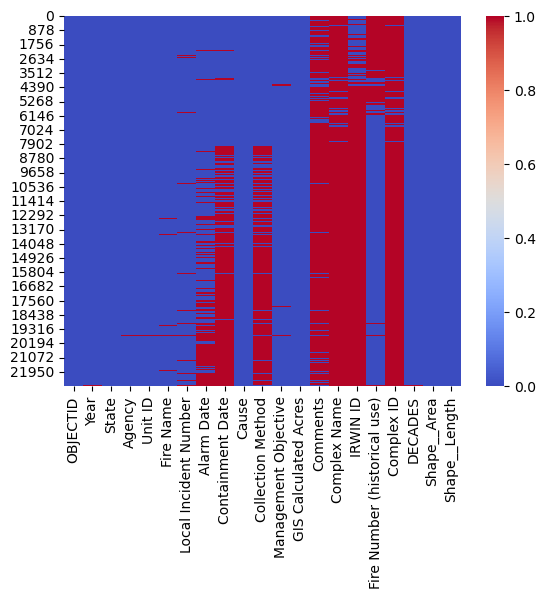

In [10]:
# Heatmap of missing values
# Hint: sns.heatmap(df.isna(), ...)

sns.heatmap(calfire.isna(), cmap='coolwarm')

<Axes: >

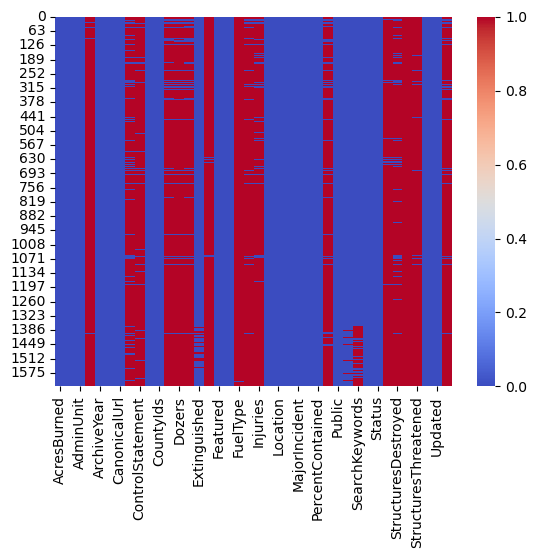

In [11]:
sns.heatmap(kaggle.isna(), cmap='coolwarm')

<Axes: >

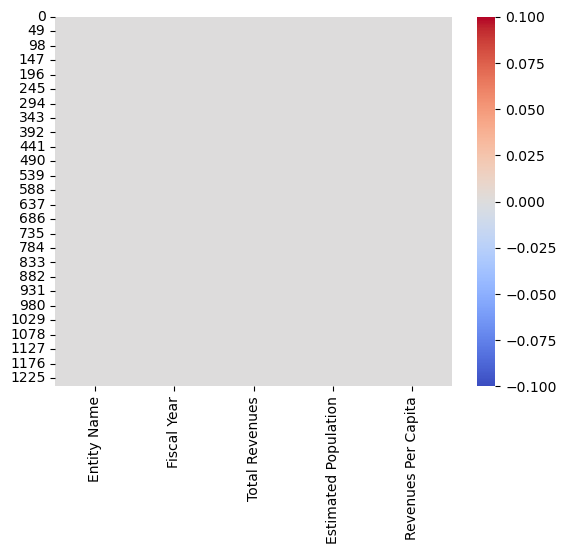

In [12]:
sns.heatmap(countrevs.isna(), cmap='coolwarm')

*(Which columns have missing values? How many? If you have any NA's, drop those observations from your dataset)*

calfire:
Agency (49)
Unit ID (61)
Year / DECADES (77 each)
Fire Name (172)
Management Objective (271)
Local Incident Number (971)
Alarm Date (5396)
Fire Number (5610)
Collection Method (12102)
Containment Date (12630)
IRWIN ID (19668)
Comments (19975)
Complex Name (22210)
Complex ID (22244)

kaggle:
AcresBurned 3
PercentContained 3
SearchDescription 17
Extinguished 59
SearchKeywords 203
ConditionStatement 352
PersonnelInvolved  1432
Engines 1445
StructuresDestroyed 1461
CrewsInvolved 1465
WaterTenders 1490
Dozers 1513
Injuries 1516
ControlStatement 1531
Helicopters 1552
StructuresDamaged 1569
StructuresThreatened 1606
AirTankers 1608
Fatalities 1615
FuelType 1624
StructuresEvacuated 1636

countrevs:
NONE!

In [13]:
# Handle missing values

dropped_calfire = (calfire[calfire.isna().sum(axis=1) < 7]).loc[:, calfire.isna().sum() <= 1000].drop(columns=['OBJECTID', 'Cause'])
# calfire.dropna() would leave us with 3 rows so we should either remove columns with mostly empty variables or filter through to only remove 
# rows that have more than 6 missing variables

dropped_kaggle = kaggle[kaggle.isna().sum(axis=1) < 17].loc[:, kaggle.isna().sum() <= 1000].drop(columns=['CountyIds', 'Final', 'Featured', 'CanonicalUrl',  'UniqueId', 'Updated'])
 # again since there are so many missing variables using .dropna() wouldve yielded an empty dataframe so filtering by a more likely number
#  based on how many columns had majority empty values. 

dropped_calfire

,Year,State,Agency,Unit ID,Fire Name,Local Incident Number,Management Objective,GIS Calculated Acres,DECADES,Shape__Area,Shape__Length
0,2025.0,CA,CDF,LDF,PALISADES,00000738,1.0,23448.8800,2020-January 2025,1.386518e+08,140231.608232
1,2025.0,CA,CDF,LAC,EATON,00009087,1.0,14056.2600,2020-January 2025,8.336393e+07,104933.207224
2,2025.0,CA,CDF,ANF,HUGHES,00250270,1.0,10396.8000,2020-January 2025,6.216064e+07,96698.599858
3,2025.0,CA,CCO,VNC,KENNETH,00003155,1.0,998.7378,2020-January 2025,5.919678e+06,15602.004849
4,2025.0,CA,CDF,LDF,HURST,00003294,1.0,831.3855,2020-January 2025,4.946082e+06,16094.217073
...,...,...,...,...,...,...,...,...,...,...,...
22711,1903.0,CA,CCO,VNC,SAN ANTONIO,00000000,1.0,380.2606,1950-1959,2.267494e+06,9900.989450
22712,1902.0,CA,CCO,VNC,FEROUD,00000000,1.0,731.4816,1950-1959,4.360470e+06,7945.451412
22725,1898.0,CA,CCO,VNC,LOS PADRES,00000000,1.0,20539.9500,1950-1959,1.225268e+08,56066.322158
22726,1898.0,CA,CCO,VNC,COZY DELL,00000000,1.0,2974.5850,1950-1959,1.775922e+07,18817.257350


### 4.3 Rename and Standardize Column Names

Clean up column names to be readable and consistent. The standard convention is **lowercase with underscores** (snake_case). Consistent naming is especially important before merging — both datasets need compatible column names for join keys.

*Useful methods: `.rename()`, `.columns`*

In [14]:
# Rename columns
dropped_calfire.columns = dropped_calfire.columns.str.lower().str.replace(' ', '_')

renamed_calfire = dropped_calfire.rename(columns={'gis_calculated_acres': 'acres_burned', 'fire_number_(historical_use)': 'historical_fire_number', 'fire_name': 'name', 'management_objective':'active', 'alarm_date': 'start_date'})

dropped_kaggle.columns = dropped_kaggle.columns.str.lower().str.replace(' ', '_')

countrevs.columns = countrevs.columns.str.lower().str.replace(' ', '_')
countrevs = countrevs

renamed_kaggle = dropped_kaggle.rename(columns={'acresburned': 'acres_burned', 'started': 'start_date', 'precentcontained': '%_contained', })

*(Which columns did you rename? What convention did you follow?)*
** In calfire I renamed 'gis_calculated_acres' to 'acres_burned' for uniformity, 'fire_number_(historical_use)' to 'historical_fire_number' for clarity, 'management_objective' to 'active' for uniformity, and 'alarm_date' to 'start_date' for unifomity.

                                                                                                                                            In the kaggle dataframe I 'acresburned' to 'acres_burned' for clarity, 'started' to 'start_date' for uniformity ** 


### 4.4 Fix Data Types

Based on your `.info()` output, correct any columns stored as the wrong dtype — for example, numeric columns stored as `object` due to formatting characters, or year/ID columns stored as `float`.

*Useful methods: `.astype()`, `.str.replace()` to strip formatting before casting*

In [15]:
renamed_kaggle.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1488 entries, 0 to 1630
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   acres_burned       1488 non-null   float64
 1   active             1488 non-null   bool   
 2   adminunit          1488 non-null   object 
 3   archiveyear        1488 non-null   int64  
 4   calfireincident    1488 non-null   bool   
 5   counties           1488 non-null   object 
 6   extinguished       1480 non-null   object 
 7   latitude           1488 non-null   float64
 8   location           1488 non-null   object 
 9   longitude          1488 non-null   float64
 10  majorincident      1488 non-null   bool   
 11  name               1488 non-null   object 
 12  percentcontained   1488 non-null   float64
 13  public             1488 non-null   bool   
 14  searchdescription  1486 non-null   object 
 15  searchkeywords     1428 non-null   object 
 16  start_date         1488 non-n

In [16]:
renamed_calfire.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17834 entries, 0 to 22727
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   17834 non-null  float64
 1   state                  17834 non-null  object 
 2   agency                 17834 non-null  object 
 3   unit_id                17824 non-null  object 
 4   name                   17809 non-null  object 
 5   local_incident_number  17054 non-null  object 
 6   active                 17642 non-null  float64
 7   acres_burned           17834 non-null  float64
 8   decades                17834 non-null  object 
 9   shape__area            17834 non-null  float64
 10  shape__length          17834 non-null  float64
dtypes: float64(5), object(6)
memory usage: 1.6+ MB


In [17]:
countrevs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   entity_name           1254 non-null   object
 1   fiscal_year           1254 non-null   int64 
 2   total_revenues        1254 non-null   int64 
 3   estimated_population  1254 non-null   int64 
 4   revenues_per_capita   1254 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 49.1+ KB


In [18]:
#[x[:4].astype(['int']) for x in renamed_calfire['decades']]

*(Which columns have wrong dtypes? What are they stored as vs. what they should be?)*

- calfire had the year inside a string.

In [19]:
# Fix data types
renamed_calfire['year'] = [int(x) for x in renamed_calfire['year']]

### 4.5 Standardize String Values

String columns used as merge keys must match exactly across both datasets — a trailing space or inconsistent capitalization will cause rows to silently fail to join. Check for and fix any inconsistencies.

*Useful methods: `.str.strip()`, `.str.lower()`, `.str.replace()`, `.value_counts()`*

the firename columns in both kaggle and calfire were inconsistent.

*(Which string columns did you standardize? What inconsistencies did you find?)*

In [20]:
renamed_kaggle['name'] = [x[:-5].lower() for x in renamed_kaggle['name']]
renamed_kaggle['counties'] = renamed_kaggle['counties'].str.split(',').str[0]
renamed_kaggle['counties'] = renamed_kaggle['counties'].str.strip().str.lower()

countrevs['entity_name'] = countrevs['entity_name'].str.strip().str.lower()

In [21]:
renamed_calfire['name'] = [str(x).lower() for x in renamed_calfire['name']]

In [22]:
# Standardize string values

renamed_kaggle

,acres_burned,active,adminunit,archiveyear,calfireincident,counties,extinguished,latitude,location,longitude,majorincident,name,percentcontained,public,searchdescription,searchkeywords,start_date,status
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,2013,True,tuolumne,2013-09-06T18:30:00Z,37.857000,3 miles east of Groveland along Hwy 120,-120.086000,False,rim,100.0,True,The Rim Fire was east of Groveland along Highw...,"Rim Fire, Stanislaus National Forest, Yosemite...",2013-08-17T15:25:00Z,Finalized
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,2013,True,los angeles,2013-06-08T18:30:00Z,34.585595,Angeles National Forest,-118.423176,False,powerhouse,100.0,True,The Powerhouse Fire burned in May and June 201...,"Powerhouse Fire, May 2013, June 2013, Angeles ...",2013-05-30T15:28:00Z,Finalized
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,2013,True,riverside,2013-07-30T18:00:00Z,33.709500,Hwy 243 & Hwy 74 near Mountain Center,-116.728850,False,mountain,100.0,True,The Mountain Fire burned in July 2013 off High...,"Mountain Fire, July 2013, Highway 243, Highway...",2013-07-15T13:43:00Z,Finalized
3,27440.0,False,Tahoe National Forest,2013,False,placer,2013-08-30T08:00:00Z,39.120000,"Deadwood Ridge, northeast of Foresthill",-120.650000,False,american,100.0,True,The American Fire burned in August 2013 off De...,"American Fire, August 2013, Deadwood Ridge, Fo...",2013-08-10T16:30:00Z,Finalized
4,24251.0,False,Ventura County Fire/CAL FIRE,2013,True,ventura,2013-05-11T06:30:00Z,0.000000,Southbound Highway 101 at Camarillo Springs Ro...,0.000000,True,springs,100.0,True,"The Springs Fire burned in May 2013, Southboun...","Springs Fire, May 2013, Highway 101, Camarillo...",2013-05-02T07:01:00Z,Finalized
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,15.0,False,CAL FIRE San Bernardino Unit,2019,True,san bernardino,2019-09-06T08:00:00Z,34.353667,"Old Dump Road, south of Summit Valley Road, He...",-117.343833,False,telephone,100.0,True,"The Telephone Fire started on September 2, 201...",NaN,2019-09-02T20:27:29Z,Finalized
1616,15.0,False,CAL FIRE / San Diego County Fire,2019,True,san diego,2019-06-24T11:44:00Z,33.302670,Highway 76 and Pauma Valley Road,-116.977720,False,pauma,100.0,True,"The Pauma Fire started on June 10, 2019 off hi...",June 2019,2019-06-10T14:25:00Z,Finalized
1625,10.0,False,CAL FIRE Tehama-Glenn Unit,2019,True,tehama,2019-10-08T09:52:00Z,39.847708,"Inghram Road, South Corning",-122.160416,False,inghram,100.0,True,"The Inghram Fire started October 8, 2019 off I...",NaN,2019-10-09T09:52:52.477Z,Finalized
1626,10.0,False,CAL FIRE Amador-El Dorado Unit,2019,True,amador,2019-09-25T17:00:00Z,38.332083,"Electra Road and Highway 49, east of Jackson",-120.671310,True,electra,100.0,True,The Electra Fire started September 25. 2019 of...,"Electra Fire, September 25, 2019, Amador County.",2019-09-25T13:13:41Z,Finalized


### 4.6 Convert Datetime Columns *(if applicable)*

If your data contains date or timestamp columns stored as strings or objects, convert them to a proper `datetime` dtype. Once converted, you can extract components (year, month, day of week, quarter) as new columns for use in your analysis.

*Useful methods: `pd.to_datetime()`, `.dt.year`, `.dt.month`, `.dt.day_of_week`, `.dt.quarter`*

*If your dataset has no date columns, note that here and move on.*

*(Which column(s) did you convert? What components did you extract, and how will they be useful in your EDA?)*

In [23]:
# Convert datetime and extract components
# NOT APPLICABLE AT THE MOMENT FOR CALFIRE

# Extracted datetime componenents

renamed_kaggle['start_date'] = pd.to_datetime(renamed_kaggle['start_date'], errors='coerce')
renamed_kaggle['extinguished'] = pd.to_datetime(renamed_kaggle['extinguished'], errors='coerce')
renamed_kaggle['year'] = renamed_kaggle['start_date'].dt.year
renamed_kaggle['month'] = renamed_kaggle['start_date'].dt.month
renamed_kaggle['day_of_week'] = renamed_kaggle['start_date'].dt.dayofweek
renamed_kaggle

,acres_burned,active,adminunit,archiveyear,calfireincident,counties,extinguished,latitude,location,longitude,...,name,percentcontained,public,searchdescription,searchkeywords,start_date,status,year,month,day_of_week
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,2013,True,tuolumne,2013-09-06 18:30:00+00:00,37.857000,3 miles east of Groveland along Hwy 120,-120.086000,...,rim,100.0,True,The Rim Fire was east of Groveland along Highw...,"Rim Fire, Stanislaus National Forest, Yosemite...",2013-08-17 15:25:00+00:00,Finalized,2013.0,8.0,5.0
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,2013,True,los angeles,2013-06-08 18:30:00+00:00,34.585595,Angeles National Forest,-118.423176,...,powerhouse,100.0,True,The Powerhouse Fire burned in May and June 201...,"Powerhouse Fire, May 2013, June 2013, Angeles ...",2013-05-30 15:28:00+00:00,Finalized,2013.0,5.0,3.0
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,2013,True,riverside,2013-07-30 18:00:00+00:00,33.709500,Hwy 243 & Hwy 74 near Mountain Center,-116.728850,...,mountain,100.0,True,The Mountain Fire burned in July 2013 off High...,"Mountain Fire, July 2013, Highway 243, Highway...",2013-07-15 13:43:00+00:00,Finalized,2013.0,7.0,0.0
3,27440.0,False,Tahoe National Forest,2013,False,placer,2013-08-30 08:00:00+00:00,39.120000,"Deadwood Ridge, northeast of Foresthill",-120.650000,...,american,100.0,True,The American Fire burned in August 2013 off De...,"American Fire, August 2013, Deadwood Ridge, Fo...",2013-08-10 16:30:00+00:00,Finalized,2013.0,8.0,5.0
4,24251.0,False,Ventura County Fire/CAL FIRE,2013,True,ventura,2013-05-11 06:30:00+00:00,0.000000,Southbound Highway 101 at Camarillo Springs Ro...,0.000000,...,springs,100.0,True,"The Springs Fire burned in May 2013, Southboun...","Springs Fire, May 2013, Highway 101, Camarillo...",2013-05-02 07:01:00+00:00,Finalized,2013.0,5.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1615,15.0,False,CAL FIRE San Bernardino Unit,2019,True,san bernardino,2019-09-06 08:00:00+00:00,34.353667,"Old Dump Road, south of Summit Valley Road, He...",-117.343833,...,telephone,100.0,True,"The Telephone Fire started on September 2, 201...",NaN,2019-09-02 20:27:29+00:00,Finalized,2019.0,9.0,0.0
1616,15.0,False,CAL FIRE / San Diego County Fire,2019,True,san diego,2019-06-24 11:44:00+00:00,33.302670,Highway 76 and Pauma Valley Road,-116.977720,...,pauma,100.0,True,"The Pauma Fire started on June 10, 2019 off hi...",June 2019,2019-06-10 14:25:00+00:00,Finalized,2019.0,6.0,0.0
1625,10.0,False,CAL FIRE Tehama-Glenn Unit,2019,True,tehama,2019-10-08 09:52:00+00:00,39.847708,"Inghram Road, South Corning",-122.160416,...,inghram,100.0,True,"The Inghram Fire started October 8, 2019 off I...",NaN,NaT,Finalized,NaN,NaN,NaN
1626,10.0,False,CAL FIRE Amador-El Dorado Unit,2019,True,amador,2019-09-25 17:00:00+00:00,38.332083,"Electra Road and Highway 49, east of Jackson",-120.671310,...,electra,100.0,True,The Electra Fire started September 25. 2019 of...,"Electra Fire, September 25, 2019, Amador County.",2019-09-25 13:13:41+00:00,Finalized,2019.0,9.0,2.0


### 4.7 Merge / Combine Datasets

Now that both datasets are cleaned, combine them. Before merging:
1. Identify the column(s) you will join on (the shared key between datasets)
2. Choose the appropriate join type: `inner`, `left`, `right`, or `outer`
3. Check the shape before and after to confirm the result makes sense

*Useful method: `pd.merge()`*

> Check for unexpected NaNs in the merged result — these often reveal mismatches in your join keys.

*(What column(s) are you joining on? What join type did you choose and why? What shape do you expect? Any surprises?)*

merging kaggle and countrevs dataframes, i expected a similar shape to both the original sets but discovered that it was generating multiple dupicate rows because each fire was matched with every fiscal year in the revenue dataset. hence the later alterations, the revenue dataset was filtered to only include fiscal years within the range of the fire data, producing to one row per county per year, and the merge was performed on both county and year.

In [27]:
renamed_kaggle.shape
rev_filtered = countrevs[countrevs['fiscal_year'].between(renamed_kaggle['year'].min(), renamed_kaggle['year'].max())]
rev_unique = rev_filtered.drop_duplicates(subset=['entity_name','fiscal_year'])

In [28]:
# Merge datasets

merged_set = pd.merge(renamed_kaggle, rev_unique, left_on=['counties','year'], right_on=['entity_name','fiscal_year'], how='left')
merged_set

,acres_burned,active,adminunit,archiveyear,calfireincident,counties,extinguished,latitude,location,longitude,...,start_date,status,year,month,day_of_week,entity_name,fiscal_year,total_revenues,estimated_population,revenues_per_capita
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,2013,True,tuolumne,2013-09-06 18:30:00+00:00,37.857000,3 miles east of Groveland along Hwy 120,-120.086000,...,2013-08-17 15:25:00+00:00,Finalized,2013.0,8.0,5.0,tuolumne,2013.0,1.006464e+08,54360.0,1851.0
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,2013,True,los angeles,2013-06-08 18:30:00+00:00,34.585595,Angeles National Forest,-118.423176,...,2013-05-30 15:28:00+00:00,Finalized,2013.0,5.0,3.0,los angeles,2013.0,1.859491e+10,9958091.0,1867.0
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,2013,True,riverside,2013-07-30 18:00:00+00:00,33.709500,Hwy 243 & Hwy 74 near Mountain Center,-116.728850,...,2013-07-15 13:43:00+00:00,Finalized,2013.0,7.0,0.0,riverside,2013.0,3.158800e+09,2255059.0,1401.0
3,27440.0,False,Tahoe National Forest,2013,False,placer,2013-08-30 08:00:00+00:00,39.120000,"Deadwood Ridge, northeast of Foresthill",-120.650000,...,2013-08-10 16:30:00+00:00,Finalized,2013.0,8.0,5.0,placer,2013.0,4.967858e+08,357463.0,1390.0
4,24251.0,False,Ventura County Fire/CAL FIRE,2013,True,ventura,2013-05-11 06:30:00+00:00,0.000000,Southbound Highway 101 at Camarillo Springs Ro...,0.000000,...,2013-05-02 07:01:00+00:00,Finalized,2013.0,5.0,3.0,ventura,2013.0,1.378237e+09,835436.0,1650.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1483,15.0,False,CAL FIRE San Bernardino Unit,2019,True,san bernardino,2019-09-06 08:00:00+00:00,34.353667,"Old Dump Road, south of Summit Valley Road, He...",-117.343833,...,2019-09-02 20:27:29+00:00,Finalized,2019.0,9.0,0.0,san bernardino,2019.0,5.123351e+09,2192203.0,2337.0
1484,15.0,False,CAL FIRE / San Diego County Fire,2019,True,san diego,2019-06-24 11:44:00+00:00,33.302670,Highway 76 and Pauma Valley Road,-116.977720,...,2019-06-10 14:25:00+00:00,Finalized,2019.0,6.0,0.0,san diego,2019.0,5.184173e+09,3351786.0,1547.0
1485,10.0,False,CAL FIRE Tehama-Glenn Unit,2019,True,tehama,2019-10-08 09:52:00+00:00,39.847708,"Inghram Road, South Corning",-122.160416,...,NaT,Finalized,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1486,10.0,False,CAL FIRE Amador-El Dorado Unit,2019,True,amador,2019-09-25 17:00:00+00:00,38.332083,"Electra Road and Highway 49, east of Jackson",-120.671310,...,2019-09-25 13:13:41+00:00,Finalized,2019.0,9.0,2.0,amador,2019.0,9.194252e+07,38294.0,2401.0


### 4.8 Filter to Relevant Rows *(if applicable)*

If your merged dataset contains rows outside the scope of your research question (e.g., wrong time period, wrong geography, placeholder values, subtotals that would double-count), filter them out now.

*Useful methods: boolean indexing with `&`, `|`; `.between()`, `.isin()`*

*If all rows are in scope, explain why.*

filtered out dates that didnt correlate, and counties that werent included in the countrev dataframe.

*(What rows did you filter out? Why are they out of scope? How many rows did you remove?)*

In [29]:
# Filter to relevant rows (if applicable)
merged_set = merged_set[merged_set['year'].between(2013, 2019)]
merged_set = merged_set[merged_set['counties'].isin(countrevs['entity_name'].str.lower())]

<a id="summary-stats"></a>
---
## 5. Summary Statistics *(5 pts)*

Show the final cleaned, merged dataset in condensed form, then provide summary statistics for the key variables in your analysis. Write a 3–5 sentence interpretation: what stands out? Any outliers, surprising ranges, or skewed distributions worth noting?

*Useful methods: `.head()`, `.info()`, `.describe()`*

In [30]:
# Final dataset — shape, info, and preview
merged_set.shape
merged_set.info()
merged_set.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1481 entries, 0 to 1487
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   acres_burned          1481 non-null   float64            
 1   active                1481 non-null   bool               
 2   adminunit             1481 non-null   object             
 3   archiveyear           1481 non-null   int64              
 4   calfireincident       1481 non-null   bool               
 5   counties              1481 non-null   object             
 6   extinguished          1473 non-null   datetime64[ns, UTC]
 7   latitude              1481 non-null   float64            
 8   location              1481 non-null   object             
 9   longitude             1481 non-null   float64            
 10  majorincident         1481 non-null   bool               
 11  name                  1481 non-null   object             
 12  percentcont

,acres_burned,active,adminunit,archiveyear,calfireincident,counties,extinguished,latitude,location,longitude,...,start_date,status,year,month,day_of_week,entity_name,fiscal_year,total_revenues,estimated_population,revenues_per_capita
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,2013,True,tuolumne,2013-09-06 18:30:00+00:00,37.857000,3 miles east of Groveland along Hwy 120,-120.086000,...,2013-08-17 15:25:00+00:00,Finalized,2013.0,8.0,5.0,tuolumne,2013.0,1.006464e+08,54360.0,1851.0
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,2013,True,los angeles,2013-06-08 18:30:00+00:00,34.585595,Angeles National Forest,-118.423176,...,2013-05-30 15:28:00+00:00,Finalized,2013.0,5.0,3.0,los angeles,2013.0,1.859491e+10,9958091.0,1867.0
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,2013,True,riverside,2013-07-30 18:00:00+00:00,33.709500,Hwy 243 & Hwy 74 near Mountain Center,-116.728850,...,2013-07-15 13:43:00+00:00,Finalized,2013.0,7.0,0.0,riverside,2013.0,3.158800e+09,2255059.0,1401.0
3,27440.0,False,Tahoe National Forest,2013,False,placer,2013-08-30 08:00:00+00:00,39.120000,"Deadwood Ridge, northeast of Foresthill",-120.650000,...,2013-08-10 16:30:00+00:00,Finalized,2013.0,8.0,5.0,placer,2013.0,4.967858e+08,357463.0,1390.0
4,24251.0,False,Ventura County Fire/CAL FIRE,2013,True,ventura,2013-05-11 06:30:00+00:00,0.000000,Southbound Highway 101 at Camarillo Springs Ro...,0.000000,...,2013-05-02 07:01:00+00:00,Finalized,2013.0,5.0,3.0,ventura,2013.0,1.378237e+09,835436.0,1650.0


In [31]:
# Summary statistics
merged_set[['acres_burned', 'total_revenues', 'estimated_population', 'revenues_per_capita']].describe()

,acres_burned,total_revenues,estimated_population,revenues_per_capita
count,1481.000000,1.481000e+03,1.481000e+03,1481.000000
mean,4989.216745,2.002041e+09,1.062805e+06,2081.584740
std,28566.537280,3.858736e+09,1.842136e+06,776.471307
min,0.000000,1.668286e+07,1.121000e+03,1144.000000
25%,36.000000,1.488729e+08,6.508100e+04,1685.000000
50%,100.000000,6.015444e+08,2.801010e+05,1923.000000
75%,484.000000,3.057808e+09,1.514770e+06,2243.000000
max,410203.000000,2.815990e+10,1.028373e+07,14882.000000


**Interpretation (3–5 sentences):** *(What do the summary statistics reveal about your key variables? Anything surprising going into EDA?)*

the cleaned dataset has 1,481 wildfires with matched county rev data. Acres_burned is highly uneven, 
with a median of 100 but a maximum over 410,000 acres meaning a few very large fires dominated the stats. county populations
and revenues vary greatly, and revenues per capita has some outliers. there are uneven distributions suggest that log-transformations or
careful visualization will be important in our EDA.

<a id="column-engineering"></a>
---
## 6. Column Engineering *(15 pts)*

Create at least **two new columns** that will help you answer your research question:

- **A categorical column** — group or classify your data using a condition. Use `np.where()` for a binary split, or `.apply()` for multi-level logic.
- **A numeric column** — compute something new from existing columns using arithmetic, string extraction (`.str.extract()`, `.str.split()`), or datetime components (`.dt.year`, `.dt.month`).

For each new column, explain what it represents and why it's more useful for your analysis than the raw data it came from.

**New categorical column** — *(what is it, and what condition defines it?)*

In [32]:
# Create new categorical column
# Hint: np.where(), .apply(), or .map()

#NEW CAT COL: FIRE SIZE CATEGORY
merged_set['fire_size_category'] = np.where(merged_set['acres_burned'] < 500, 'small', np.where(merged_set['acres_burned'] < 10000, 'medium', 'large'))

merged_set['fire_size_category'].value_counts()


fire_size_category
small     1116
medium     269
large       96
Name: count, dtype: int64

**New numeric column** — *(what is it, and how is it computed?)*

In [33]:
# Create new numeric column
# Hint: arithmetic, .apply()

# NEW NUMERIC COL: REV PER FIRE ACRE
merged_set['revenue_per_fire_acre'] = merged_set['total_revenues'] / merged_set['acres_burned'].replace(0, np.nan)

merged_set[['acres_burned', 'total_revenues', 'revenue_per_fire_acre']]


,acres_burned,total_revenues,revenue_per_fire_acre
0,257314.0,1.006464e+08,3.911425e+02
1,30274.0,1.859491e+10,6.142204e+05
2,27531.0,3.158800e+09,1.147361e+05
3,27440.0,4.967858e+08,1.810444e+04
4,24251.0,1.378237e+09,5.683219e+04
...,...,...,...
1482,15.0,1.126147e+08,7.507649e+06
1483,15.0,5.123351e+09,3.415567e+08
1484,15.0,5.184173e+09,3.456115e+08
1486,10.0,9.194252e+07,9.194252e+06


In [34]:
# Confirm both new columns appear in your DataFrame
merged_set.head()


,acres_burned,active,adminunit,archiveyear,calfireincident,counties,extinguished,latitude,location,longitude,...,year,month,day_of_week,entity_name,fiscal_year,total_revenues,estimated_population,revenues_per_capita,fire_size_category,revenue_per_fire_acre
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,2013,True,tuolumne,2013-09-06 18:30:00+00:00,37.857000,3 miles east of Groveland along Hwy 120,-120.086000,...,2013.0,8.0,5.0,tuolumne,2013.0,1.006464e+08,54360.0,1851.0,large,391.142480
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,2013,True,los angeles,2013-06-08 18:30:00+00:00,34.585595,Angeles National Forest,-118.423176,...,2013.0,5.0,3.0,los angeles,2013.0,1.859491e+10,9958091.0,1867.0,large,614220.430435
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,2013,True,riverside,2013-07-30 18:00:00+00:00,33.709500,Hwy 243 & Hwy 74 near Mountain Center,-116.728850,...,2013.0,7.0,0.0,riverside,2013.0,3.158800e+09,2255059.0,1401.0,large,114736.121427
3,27440.0,False,Tahoe National Forest,2013,False,placer,2013-08-30 08:00:00+00:00,39.120000,"Deadwood Ridge, northeast of Foresthill",-120.650000,...,2013.0,8.0,5.0,placer,2013.0,4.967858e+08,357463.0,1390.0,large,18104.439650
4,24251.0,False,Ventura County Fire/CAL FIRE,2013,True,ventura,2013-05-11 06:30:00+00:00,0.000000,Southbound Highway 101 at Camarillo Springs Ro...,0.000000,...,2013.0,5.0,3.0,ventura,2013.0,1.378237e+09,835436.0,1650.0,large,56832.188528


<a id="visualizations"></a>
---
## 7. Visualizations *(20 pts)*

Create at least **three visualizations** that help answer your research question. Each plot should serve a clear purpose — don't plot for the sake of plotting.

**Requirements:**
- At least **one plot must be faceted or grouped** (use `hue=`, `col=`, `row=` in Seaborn, or `facet_wrap()` / `facet_grid()` in plotnine)
- Every plot must have a title, axis labels, and a legend if multiple groups are shown
- Write 2–3 sentences of interpretation after each plot: what does it tell you?

> Before each plot, write a markdown cell answering: *What question does this visualization answer?*

### 7.1 Visualization 1

*What question does this plot answer?*

fire size per county and how many of each

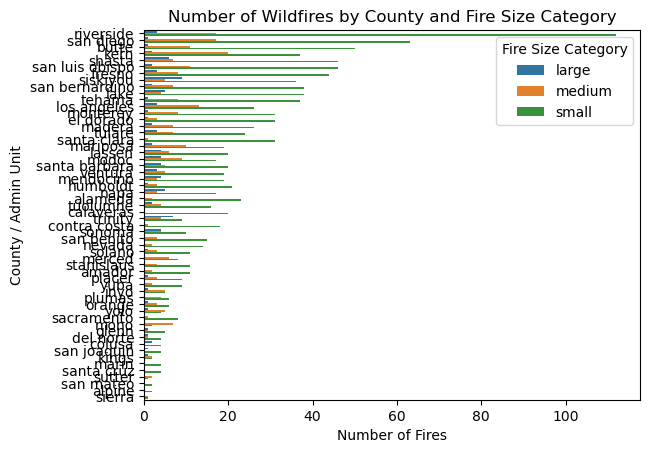

In [35]:
# Visualization 1

sns.countplot( data=merged_set, y='entity_name', hue='fire_size_category', order=merged_set['entity_name'].value_counts().index)
plt.title("Number of Wildfires by County and Fire Size Category")
plt.xlabel("Number of Fires")
plt.ylabel("County / Admin Unit")
plt.legend(title="Fire Size Category")
plt.show()

**Interpretation:** *(2–3 sentences)*

* spread of fire size per county, has majority small fires * 

### 7.2 Visualization 2 *(must be faceted or grouped)*

*What subgroup comparison are you making, and why is it meaningful for your research question?*

comparing fire size across fiscal years, grouped by fire size category. meaningful because it allows to see trends over time for example, whether large fires have become more frequent in recent years, which is critical for understanding wildfire risk evolution and resource budgeting.

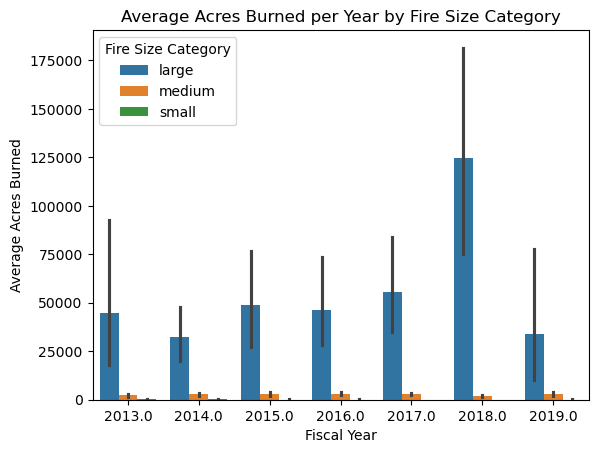

In [36]:
# Visualization 2 — faceted or grouped
# Hint: hue=, col=, row= in Seaborn; facet_wrap() or facet_grid() in plotnine

sns.barplot(data=merged_set, x='fiscal_year', y='acres_burned', hue='fire_size_category')
plt.title("Average Acres Burned per Year by Fire Size Category")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Acres Burned")
plt.legend(title="Fire Size Category")
plt.show()

**Interpretation:** *(2–3 sentences — what does the subgroup comparison reveal?)*

* shows how the scale of wildfires varies across years for small, medium, and large fires. It highlights whether large fires are increasing in frequency or size over time, providing insight into trends that can inform prevention and response planning. patterns of growing fire size in certain years may point clear factors and influences.

### 7.3 Visualization 3

*What question does this plot answer?*

- does fire size have an impact on county rev?

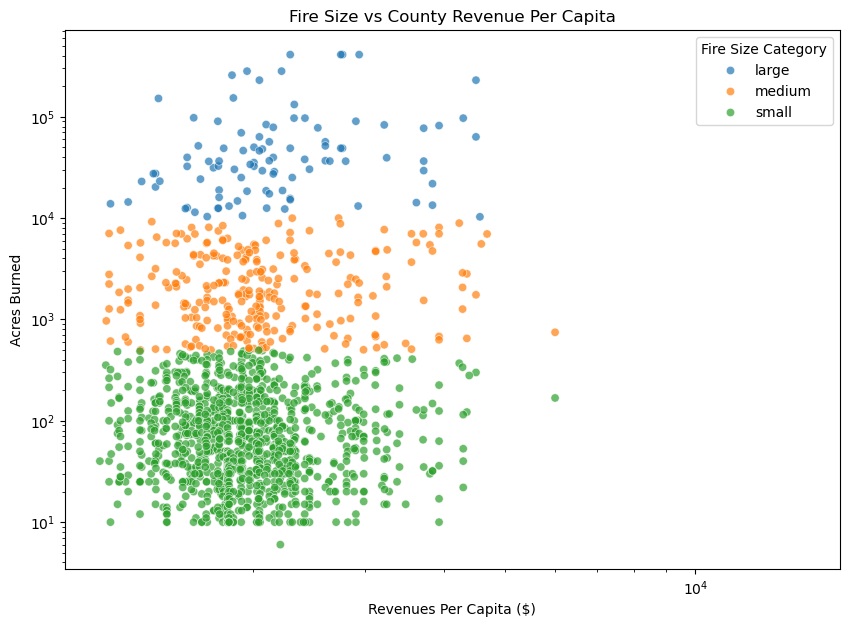

In [37]:
# Visualization 3

plt.figure(figsize=(10,7))
sns.scatterplot(data=merged_set, x='revenues_per_capita', y='acres_burned', hue='fire_size_category', alpha=0.7)
plt.title('Fire Size vs County Revenue Per Capita')
plt.xlabel('Revenues Per Capita ($)')
plt.ylabel('Acres Burned')
plt.legend(title='Fire Size Category')
plt.yscale('log') 
plt.xscale('log') 
plt.show()


**Interpretation:** *(2–3 sentences)*

shows how fire sizes vary across counties with different per capita revenues. using the log scales, we can see that while small fires occur in counties across all revenue levels, the largest fires tend to cluster in mid to lower revenue counties. color fire by size category highlights that extreme events have a disproportionate impact.

### Add a Visualization 4 block if you have more to show

<a id="grouped-analysis"></a>
---
## 8. Grouped Analysis *(10 pts)*

Use `.groupby()` and an aggregation function to summarize your data along a meaningful dimension — by region, time period, category, demographic group, or another variable relevant to your research question. Visualize the result and interpret what the subgroups reveal.

> Think about which grouping makes the most sense for your data and research question. Sort your result before plotting so the chart is readable.

*Useful methods: `.groupby()`, `.agg()`, `.mean()`, `.sum()`, `.count()`, `.median()`, `.sort_values()`*

*(What are you grouping by? What are you measuring within each group? Why is this the right question to ask given your research problem?)*

In [38]:
# Grouped aggregation

grouped = merged_set.groupby('fire_size_category').agg({'acres_burned': 'mean', 'revenue_per_fire_acre': 'mean'}).reset_index()
grouped = grouped.sort_values('acres_burned', ascending=False)
grouped

,fire_size_category,acres_burned,revenue_per_fire_acre
0,large,68390.041667,5.177426e+04
1,medium,2642.167286,1.516163e+06
2,small,101.113799,4.762151e+07


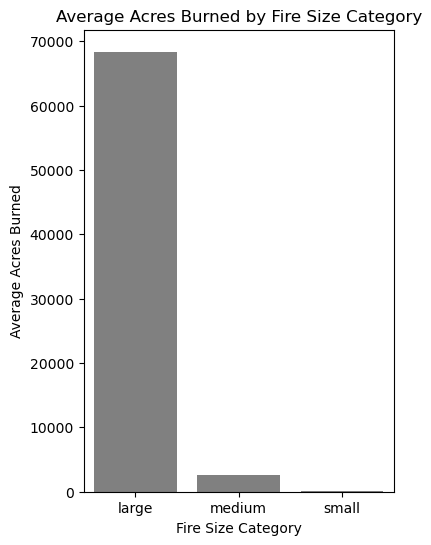

In [39]:
# Visualize the grouped result

plt.figure(figsize=(4,6))
sns.barplot(data=grouped, x='fire_size_category', y='acres_burned', color='grey')
plt.title('Average Acres Burned by Fire Size Category')
plt.xlabel('Fire Size Category')
plt.ylabel('Average Acres Burned')
plt.show()

**Subgroup finding (2–3 sentences):** *(Which group stands out? What does this pattern mean for your research question?)*

*the largest fires unsurprisingly have the highest average acres burned, confirming our fire_size_category classification. smaller fires, while more frequent, contribute far less to total burned area. compared with revenue_per_fire_acre can also reveal which counties face the greatest economic burden per acre of land affected.

<a id="summary-findings"></a>
---
## 9. Summary of Findings *(10 pts)*

Write **1–2 paragraphs** capturing where your project stands right now:

1. **Findings so far** — Describe at least **2 specific patterns or insights** from your EDA. Reference your actual results (e.g., *"the grouped analysis showed that X had twice the rate of Y compared to Z"*).
2. **Open questions** — Identify at least **2 questions your final project still needs to answer**. These become your roadmap for the work ahead.

*This is a working draft of your final project's Summary section. When you write the final version, you'll have more complete findings — but the questions you name here will guide everything that comes next.*

our analysis shows that large fires despite being less frequent account for the majority of acres burned, while smaller fires occur more often but impact less land understandly. counties with higher total revenues often experience larger fires per acre, suggesting a likely link between resources and fire outcomes. seasonal patterns are identifiable, indicating a peak fire season in California.

It is unclear how socio-economic factors like revenue per capita affect containment and suppression efforts. also, geographic clusters of repeated fire activity need further exploration to understand the relationship with population density and agency resource allocation. I hope to yse these insights to focuse on factors and predictive patterns in wildfire occurrence and impact.

<a id="bonus"></a>
---
## Bonus. API Enrichment *(+5 points)*
*(→ Final project: 3. Data Preparation)*

In Lecture 26 you learned how to fetch data from an external API and enrich a DataFrame with it. This bonus asks you to add **at least one new column** to your dataset by calling an external API.

📓 **See the companion notebook for a complete walkthrough:** `task7_api_worked_example.ipynb`  
The worked example uses the Wikipedia REST API (no key required) and walks through the exact pattern: test one value → wrap in a function → loop over unique values → map back to your DataFrame. It also includes a table of APIs matched to each dataset.

---

**To earn full bonus credit, show:**

1. Your API call working on a single test value (status code = 200, JSON inspected)  
2. A loop or batch call that collects results for the relevant column in your DataFrame  
3. A `df.head()` confirming the new column appears in your actual dataset

Then write **1–2 sentences** answering: *What did the API add, and how will you use this new column in your EDA or final project?*

In [41]:
def get_wiki_sum(title):
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{title}"
    response = requests.get(url)
    if response.status_code == 200:
        json_data = response.json()
        return json_data.get("extract", "No summary available")
    else:
        return "No summary available"

merged_set['wiki_summary'] = merged_set['name'].apply(get_wiki_sum)
merged_set.head()

,acres_burned,active,adminunit,archiveyear,calfireincident,counties,extinguished,latitude,location,longitude,...,month,day_of_week,entity_name,fiscal_year,total_revenues,estimated_population,revenues_per_capita,fire_size_category,revenue_per_fire_acre,wiki_summary
0,257314.0,False,Stanislaus National Forest/Yosemite National Park,2013,True,tuolumne,2013-09-06 18:30:00+00:00,37.857000,3 miles east of Groveland along Hwy 120,-120.086000,...,8.0,5.0,tuolumne,2013.0,1.006464e+08,54360.0,1851.0,large,391.142480,No summary available
1,30274.0,False,USFS Angeles National Forest/Los Angeles Count...,2013,True,los angeles,2013-06-08 18:30:00+00:00,34.585595,Angeles National Forest,-118.423176,...,5.0,3.0,los angeles,2013.0,1.859491e+10,9958091.0,1867.0,large,614220.430435,No summary available
2,27531.0,False,CAL FIRE Riverside Unit / San Bernardino Natio...,2013,True,riverside,2013-07-30 18:00:00+00:00,33.709500,Hwy 243 & Hwy 74 near Mountain Center,-116.728850,...,7.0,0.0,riverside,2013.0,3.158800e+09,2255059.0,1401.0,large,114736.121427,No summary available
3,27440.0,False,Tahoe National Forest,2013,False,placer,2013-08-30 08:00:00+00:00,39.120000,"Deadwood Ridge, northeast of Foresthill",-120.650000,...,8.0,5.0,placer,2013.0,4.967858e+08,357463.0,1390.0,large,18104.439650,No summary available
4,24251.0,False,Ventura County Fire/CAL FIRE,2013,True,ventura,2013-05-11 06:30:00+00:00,0.000000,Southbound Highway 101 at Camarillo Springs Ro...,0.000000,...,5.0,3.0,ventura,2013.0,1.378237e+09,835436.0,1650.0,large,56832.188528,No summary available


---
# ✅ Before You Submit

1. Go back to the **Checklist** at the top and fill in every ✓ / ✗
2. Run **Kernel → Restart & Run All** — your notebook must execute top-to-bottom without errors
3. Make sure your **GitHub repo link** is visible somewhere in this notebook
4. Submit the `.ipynb` file to **Canvas**
5. **Push** the updated notebook to your **GitHub repo**